<a href="https://colab.research.google.com/github/Kidkudos77/personalportfolio/blob/main/Chapter2_Inference_Binary_Data_cls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
# imports the stats module from the scipy library and renames it to stats for convenience in the code.
import scipy.stats as stats

# 100 COVID-19 tests with 20% positive
# generate the test results as 2000 binary random numbers  (x = 1: test positive, x=0: test negative)
N = 50
positive_rate = 0.2
states = np.arange(2) # Just [0 1]
probs  = np.array([1- positive_rate, positive_rate])
berndist = stats.rv_discrete(name= 'berndist' , values = (states, probs))   #generate Bernoulli distribution data
x = berndist.rvs(size=N) #sampling distribution

print(x)

[0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 1 1 0 0 0 1 0 0 1 0 0]


The positive rate with the highest likelihood is: 0.13986086086086086


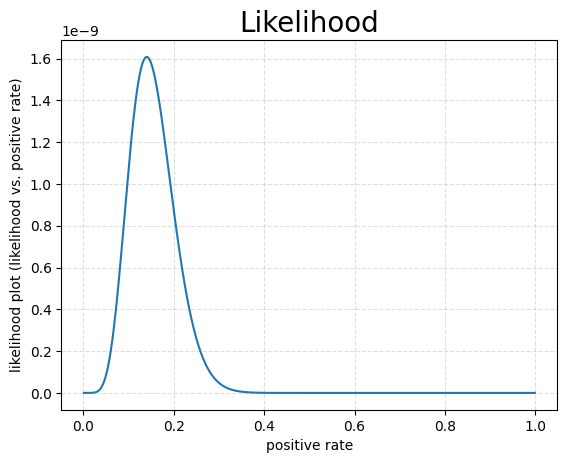

In [17]:
# Want to estimate the positive_rate from the data
# The maxmimum likelhood estimate purely depends on the data

mu_range = np.linspace(0.001, 0.999, 1000) # 1000 values between 0.001 and 0.999. These are candidate values for mu
X = x.reshape(-1, 1); #converting array x into column, 50X1

# loglikelihood = the logarithm of Equation (2.4) of our lecture note
loglikelihood = X*np.log(mu_range) + (1-X) *np.log(1-mu_range) # perform element-wise multiplication
loglikelihood = np.sum(loglikelihood, axis=0) # summation over all 50 samples
likelihood    = np.exp(loglikelihood)#
import matplotlib.pyplot as plt
plt.title('Likelihood', fontsize=20)
plt.plot(mu_range, likelihood)
plt.xlabel('positive rate')
plt.ylabel('likelihood plot (likelihood vs. positive rate)')
plt.grid(alpha=0.4, linestyle='--') #alpha sets the transparency of the gridlines

# The comment calls it p_range, but your variable is mu_range
# It is computationally safer to find the max of the loglikelihood to avoid underflow
max_index = np.argmax(loglikelihood)

# Use that index to pull the corresponding positive rate
best_rate = mu_range[max_index]

print("The positive rate with the highest likelihood is:", best_rate)

# Question: Which positive rate gives the highest likelihood?
# suppose p_range and likelihood are your arrays

#The positive rate with the highest likelihood is: 0.19880180180180182




In [18]:
# Let's check the most accurate answer:
k = np.argmax(loglikelihood)
MLE_estimate = mu_range[k]

print("The p_range value that leads to maximum likelihood is: ", MLE_estimate)

# We can also calculate the MLE using the formula (2.5)
print("The theoretical MLE is: ", np.mean(x))

The p_range value that leads to maximum likelihood is:  0.13986086086086086
The theoretical MLE is:  0.14


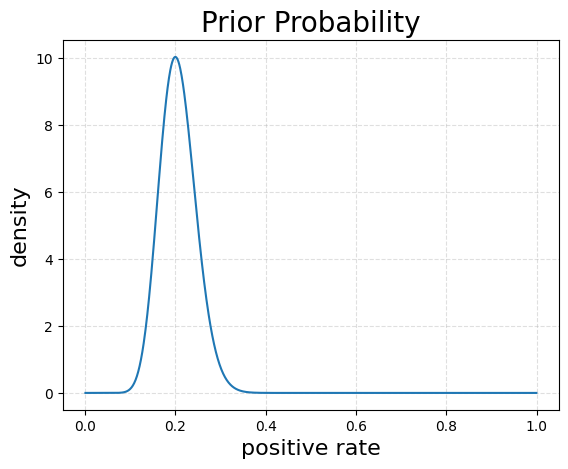

In [19]:

# Bayesian Estimate uses some prior knowledge on the positive rate
# For example, suppose that the historical positive rate of COVID-like tests followed a Beta Distribution with parameters a and b
a = 21
b = 81

prior = stats.beta.pdf(x=mu_range, a= a, b=b)

plt.plot(mu_range, prior)
# Add a title
plt.title('Prior Probability', fontsize=20)
# Add X and y Label
plt.xlabel('positive rate', fontsize=16)
plt.ylabel('density', fontsize=16)
# Add a grid
plt.grid(alpha=.4, linestyle='--')
# Show the plot
plt.show()


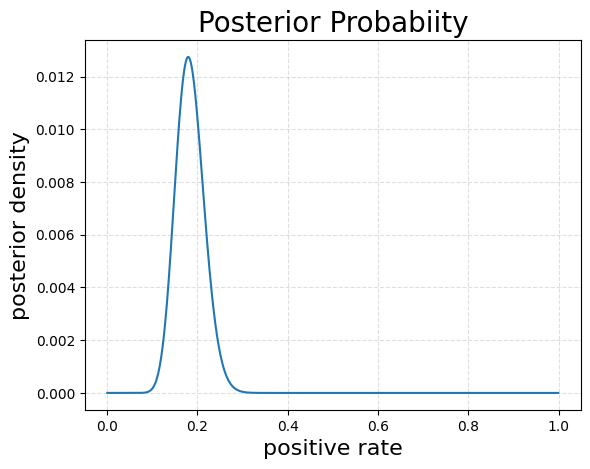

The positive rate with the highest posterior density (MAP) is: 0.17982082082082082


In [21]:
# Posterior Probability-  Maximum A Priori (MAP)
posterior_prob = (likelihood * prior) / np.sum(likelihood * prior)
plt.plot(mu_range, posterior_prob)
# Add a title
plt.title('Posterior Probabiity', fontsize=20)
# Add X and y Label
plt.xlabel('positive rate', fontsize=16)
plt.ylabel('posterior density', fontsize=16)
# Add a grid
plt.grid(alpha=.4, linestyle='--')
# Show the plot
plt.show()

# Question: Which positive rate gives the highest likelihood?
# Find the index of the highest value in the posterior probability array
map_index = np.argmax(posterior_prob)

# Map that index back to your candidate positive rates
map_estimate = mu_range[map_index]

print("The positive rate with the highest posterior density (MAP) is:", map_estimate)


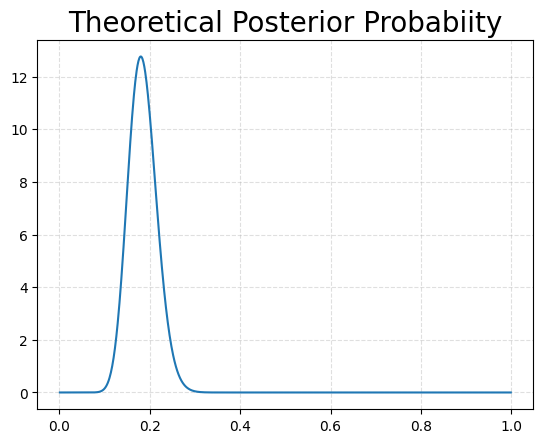

In [24]:

#Let's check the theoretical value from lecture slide Equation below (2.7)
posterior_prob_theory = stats.beta.pdf(mu_range, a + np.sum(x), b + len(x) - np.sum(x))
plt.plot(mu_range, posterior_prob_theory)
plt.title('Theoretical Posterior Probabiity', fontsize=20)
plt.grid(alpha=.4, linestyle='--')
plt.show()
# the two plots should be very close!

In [26]:
# Questions:
# please compare the results for MLE, MAP and true value for mu

# Find the best mu according to MAP method
k = np.argmax(posterior_prob)
MAP_estimate = mu_range[k]

print('MLE of Positive Rate = '+'{:10.4f}'.format(MLE_estimate))
print('MAP of Positive Rate = '+'{:10.4f}'.format(MAP_estimate))
print('True Positive Rate   = '+'{:10.4f}'.format(positive_rate))

MLE of Positive Rate =     0.1399
MAP of Positive Rate =     0.1798
True Positive Rate   =     0.2000
